# Tesla Deliveries — End-to-End ML Pipeline
**Author:** Jitisha Karnani

**Dataset:** Tesla EV Deliveries & Production Data (2015–2025)  

**Target:** `Estimated_Deliveries`

### Pipeline Overview
1. Data Loading & Null Audit  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Encoding & Scaling  
5. Chronological Train / Test Split  
6. Baseline + Multi-Model Regression  
7. Model Evaluation & Comparison  
8. Feature Importance  
9. Model Persistence

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
path = "tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(path)
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape  : (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Null Audit & Data Types
Zero nulls in this dataset, but we check defensively and handle any that might appear in new data.

In [3]:
# Null audit
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().mean() * 100).round(2),
    'dtype'     : df.dtypes
})
print(null_df.to_string())


df[df.select_dtypes(include='number').columns] = (
    df.select_dtypes(include='number').fillna(df.select_dtypes(include='number').median())
)
df[df.select_dtypes(include='object').columns] = (
    df.select_dtypes(include='object').fillna('Unknown')
)
print("\n✓ No nulls remaining" if df.isnull().sum().sum() == 0 else "⚠ Nulls still present")

                      null_count  null_%    dtype
Year                           0     0.0    int64
Month                          0     0.0    int64
Region                         0     0.0   object
Model                          0     0.0   object
Estimated_Deliveries           0     0.0    int64
Production_Units               0     0.0    int64
Avg_Price_USD                  0     0.0  float64
Battery_Capacity_kWh           0     0.0    int64
Range_km                       0     0.0    int64
CO2_Saved_tons                 0     0.0  float64
Source_Type                    0     0.0   object
Charging_Stations              0     0.0    int64

✓ No nulls remaining


In [4]:
print(df.describe().T.to_string())

                       count          mean           std       min        25%        50%          75%        max
Year                  2640.0   2020.000000      3.162877   2015.00   2017.000   2020.000    2023.0000    2025.00
Month                 2640.0      6.500000      3.452707      1.00      3.750      6.500       9.2500      12.00
Estimated_Deliveries  2640.0   9922.199621   3935.950093     48.00   7292.000   9857.000   12510.2500   25704.00
Production_Units      2640.0  10655.847348   4260.600858     50.00   7828.250  10546.500   13469.0000   28939.00
Avg_Price_USD         2640.0  84907.340330  20123.258036  50003.70  67726.365  85058.510  102373.0425  119965.36
Battery_Capacity_kWh  2640.0     87.059470     20.836265     60.00     75.000     82.000     100.0000     120.00
Range_km              2640.0    500.257576    120.868549    330.00    418.000    470.000     586.2500     719.00
CO2_Saved_tons        2640.0    744.076989    353.221224      3.07    499.620    699.515     943

## 3. Exploratory Data Analysis (EDA)
Five complementary views: delivery growth over time, model-share breakdown, regional comparison,
price trend, and a correlation heatmap.

In [5]:

df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date range: {df['Date'].min().date()}  →  {df['Date'].max().date()}")

Date range: 2015-01-01  →  2025-12-01


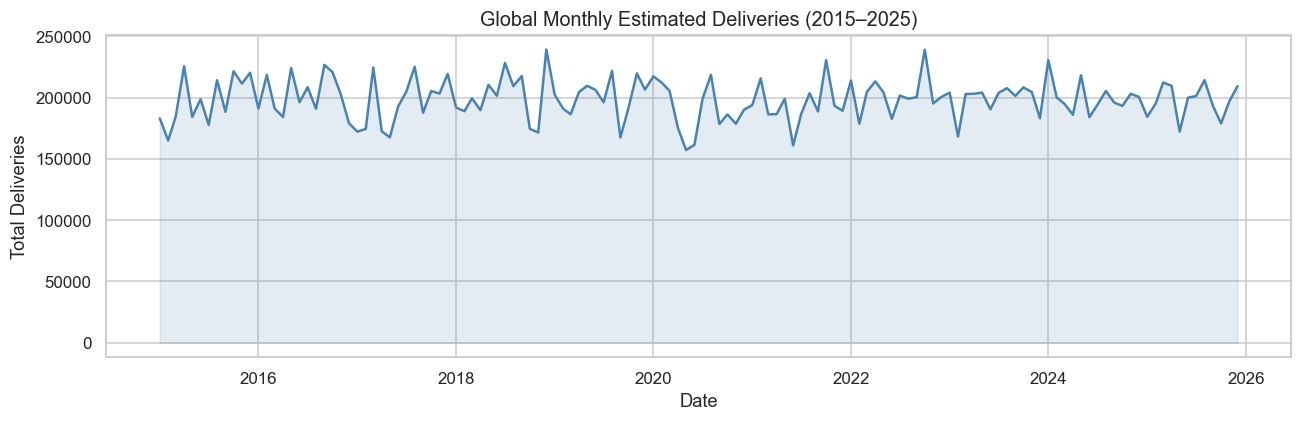

In [6]:
# ── EDA 1: Global monthly deliveries over time ──
monthly_total = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(monthly_total['Date'], monthly_total['Estimated_Deliveries'],
         linewidth=1.6, color='steelblue')
plt.fill_between(monthly_total['Date'], monthly_total['Estimated_Deliveries'],
                 alpha=0.15, color='steelblue')
plt.title("Global Monthly Estimated Deliveries (2015–2025)", fontsize=13)
plt.xlabel("Date"); plt.ylabel("Total Deliveries")
plt.tight_layout(); plt.show()

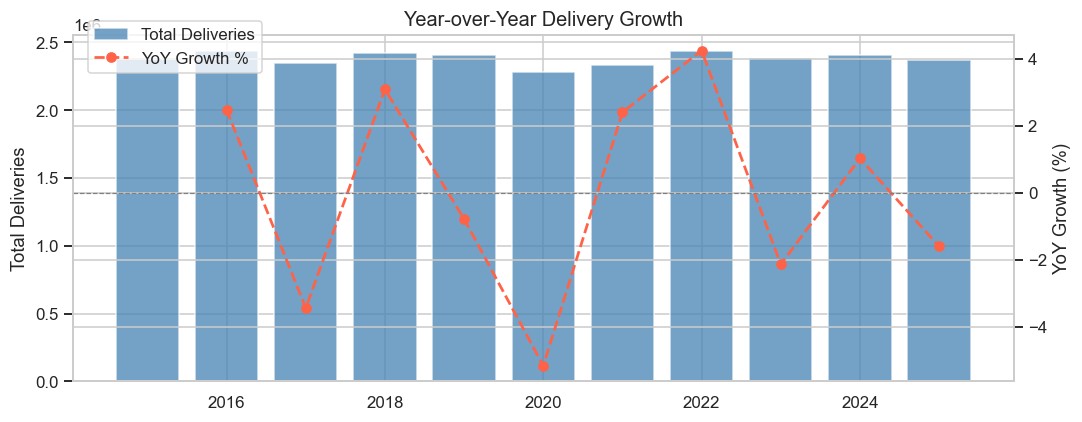

 Year  Estimated_Deliveries  YoY_Growth_%
 2015               2375267           NaN
 2016               2434081      2.476101
 2017               2350517     -3.433082
 2018               2423104      3.088129
 2019               2404230     -0.778918
 2020               2280336     -5.153168
 2021               2335116      2.402278
 2022               2434220      4.244072
 2023               2382375     -2.129840
 2024               2406899      1.029393
 2025               2368462     -1.596951


In [7]:
# ── EDA 2: Year-over-year total deliveries ──
yoy = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
yoy['YoY_Growth_%'] = yoy['Estimated_Deliveries'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(yoy['Year'], yoy['Estimated_Deliveries'], color='steelblue', alpha=0.75, label='Total Deliveries')
ax1.set_ylabel("Total Deliveries")
ax2 = ax1.twinx()
ax2.plot(yoy['Year'][1:], yoy['YoY_Growth_%'][1:], 'o--', color='tomato', linewidth=1.8, label='YoY Growth %')
ax2.set_ylabel("YoY Growth (%)")
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax1.set_title("Year-over-Year Delivery Growth", fontsize=13)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.95))
plt.tight_layout(); plt.show()

print(yoy.to_string(index=False))

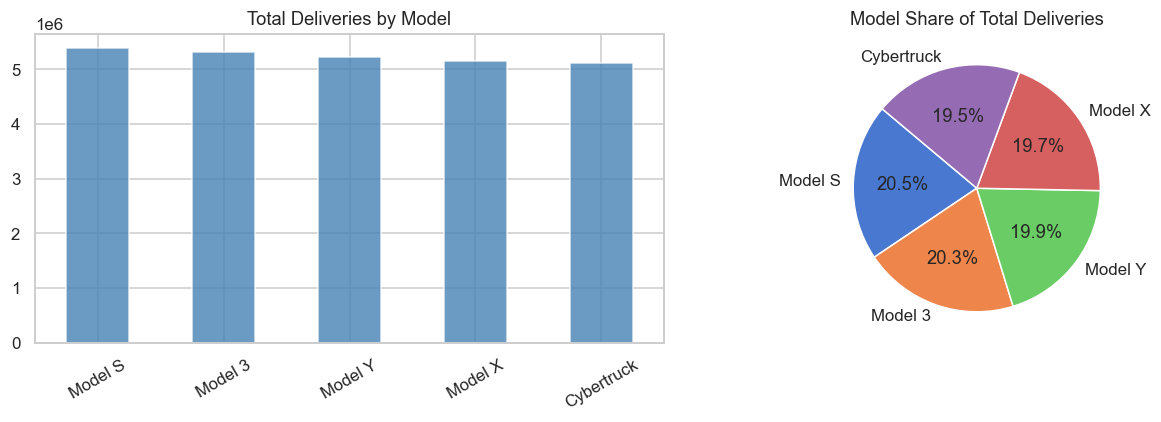

In [8]:
# ── EDA 3: Deliveries by Model ──
model_share = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

model_share.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title("Total Deliveries by Model"); ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=30)

ax2.pie(model_share, labels=model_share.index, autopct='%1.1f%%', startangle=140)
ax2.set_title("Model Share of Total Deliveries")

plt.tight_layout(); plt.show()

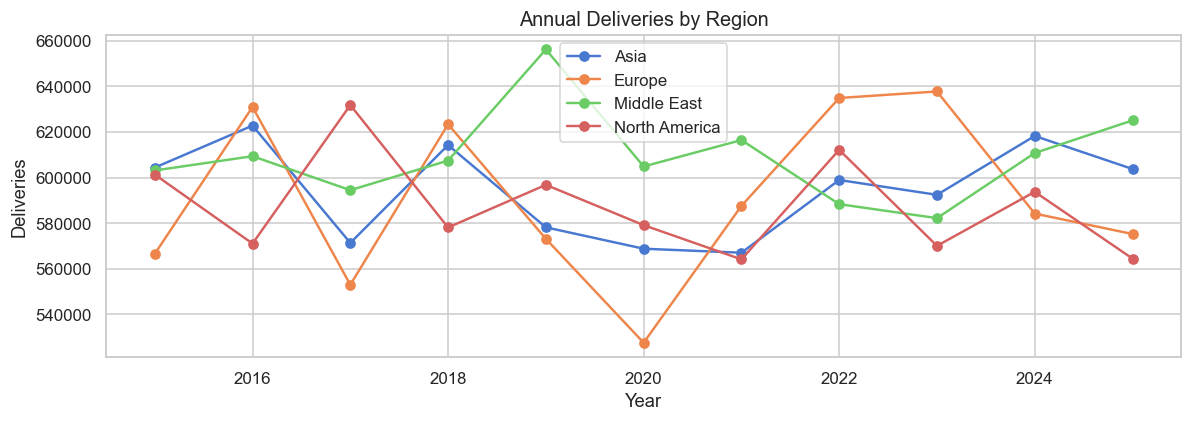

In [9]:
# ── EDA 4: Deliveries by Region ──
region_year = df.groupby(['Year','Region'])['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(11, 4))
for region in region_year['Region'].unique():
    sub = region_year[region_year['Region'] == region]
    plt.plot(sub['Year'], sub['Estimated_Deliveries'], marker='o', linewidth=1.6, label=region)

plt.title("Annual Deliveries by Region", fontsize=13)
plt.xlabel("Year"); plt.ylabel("Deliveries")
plt.legend(); plt.tight_layout(); plt.show()

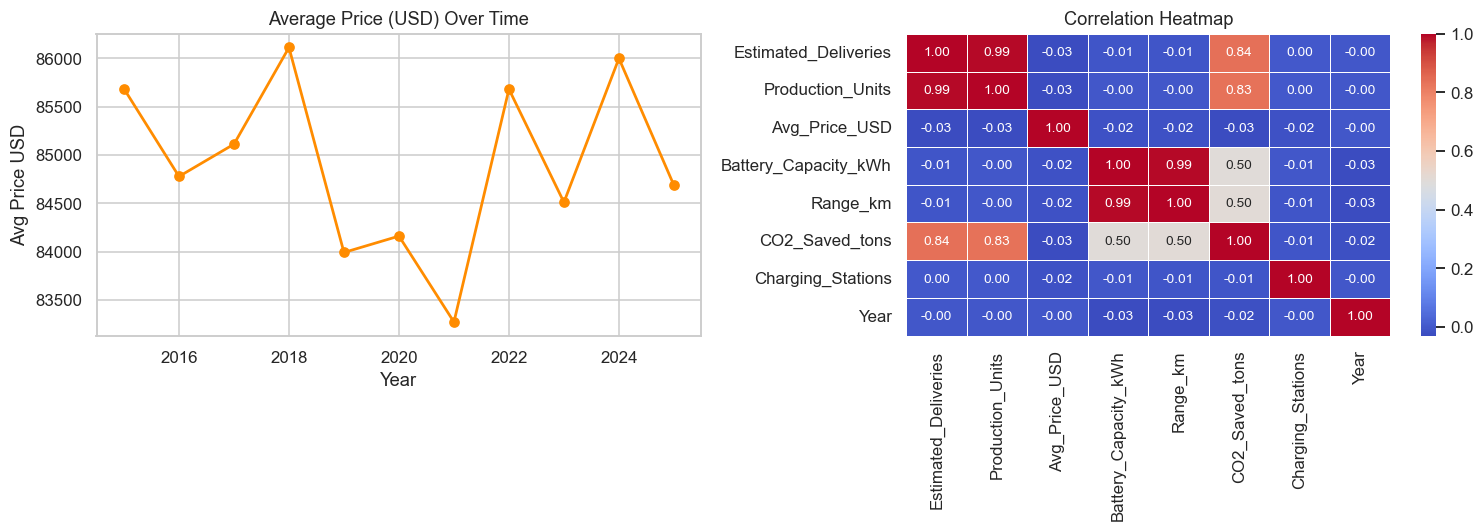

In [10]:
# ── EDA 5: Avg Price trend and Correlation Heatmap ──
price_trend = df.groupby('Year')['Avg_Price_USD'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(price_trend['Year'], price_trend['Avg_Price_USD'], 'o-', color='darkorange', linewidth=1.8)
ax1.set_title("Average Price (USD) Over Time"); ax1.set_xlabel("Year"); ax1.set_ylabel("Avg Price USD")

corr_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
             'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations','Year']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax2,
            linewidths=0.4, annot_kws={'size': 9})
ax2.set_title("Correlation Heatmap")

plt.tight_layout(); plt.show()

## 4. Feature Engineering
Four new features that improve signal significantly:

| Feature | Rationale |
|---|---|
| `month_sin` / `month_cos` | Cyclical month encoding — fixes the broken Dec→Jan boundary |
| `efficiency_ratio` | Deliveries ÷ Production; captures fulfilment performance |
| `lag_1`, `lag_3` | Previous 1- and 3-month deliveries per Region+Model group |
| `roll_3` | 3-month rolling mean — smoothed recent trend |

In [11]:
# ── Cyclical month encoding ──────────────────────────────────────────────────
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# ── Production efficiency ratio ──────────────────────────────────────────────
df['efficiency_ratio'] = df['Estimated_Deliveries'] / df['Production_Units']

# ── Lag & rolling features (per Region + Model group) ───────────────────────
df = df.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)

df['lag_1']  = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['lag_3']  = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)
df['roll_3'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Sort back chronologically and fill NaNs introduced by shift
df = df.sort_values('Date').reset_index(drop=True)
df[['lag_1','lag_3','roll_3']] = df[['lag_1','lag_3','roll_3']].fillna(
    df[['lag_1','lag_3','roll_3']].median()
)

print("New features added: month_sin, month_cos, efficiency_ratio, lag_1, lag_3, roll_3")
print(f"Dataset shape after feature engineering: {df.shape}")
df[['Date','Region','Model','Estimated_Deliveries',
    'month_sin','month_cos','efficiency_ratio','lag_1','lag_3','roll_3']].head(8)

New features added: month_sin, month_cos, efficiency_ratio, lag_1, lag_3, roll_3
Dataset shape after feature engineering: (2640, 19)


,Date,Region,Model,Estimated_Deliveries,month_sin,month_cos,efficiency_ratio,lag_1,lag_3,roll_3
0,2015-01-01,Asia,Cybertruck,11325,0.5,0.866025,0.952721,9857.0,9862.5,9851.833333
1,2015-01-01,North America,Model 3,9446,0.5,0.866025,0.991394,9857.0,9862.5,9851.833333
2,2015-01-01,North America,Model S,11986,0.5,0.866025,0.901068,9857.0,9862.5,9851.833333
3,2015-01-01,Asia,Model 3,8795,0.5,0.866025,0.959629,9857.0,9862.5,9851.833333
4,2015-01-01,Europe,Model S,4350,0.5,0.866025,0.918497,9857.0,9862.5,9851.833333
5,2015-01-01,Middle East,Cybertruck,8803,0.5,0.866025,0.942102,9857.0,9862.5,9851.833333
6,2015-01-01,North America,Cybertruck,6367,0.5,0.866025,0.936048,9857.0,9862.5,9851.833333
7,2015-01-01,Europe,Model 3,7597,0.5,0.866025,0.906996,9857.0,9862.5,9851.833333


## 5. Categorical Encoding
Each categorical column uses its **own** `LabelEncoder` instance so that mappings are
stored separately and can be inverted correctly later.  
Using a single shared encoder (the original bug) overwrites earlier mappings on each `fit_transform` call.

In [12]:
# Separate encoder per column — fixes the shared-encoder bug
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df['Region_enc']      = le_region.fit_transform(df['Region'])
df['Model_enc']       = le_model.fit_transform(df['Model'])
df['Source_Type_enc'] = le_source.fit_transform(df['Source_Type'])

print("Region mapping :", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model mapping  :", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))
print("Source mapping :", dict(zip(le_source.classes_, le_source.transform(le_source.classes_))))

Region mapping : {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping  : {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Source mapping : {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}


## 6. Chronological Train / Test Split
**Critical:** time-series data must never be randomly shuffled for train/test splitting.

`train_test_split(random_state=42)` mixes rows from all years, so the model trains on
2024 data and "predicts" 2015 rows — trivially easy and meaningless.

A hard date boundary ensures the model only ever sees past data during training.

In [13]:
SPLIT_DATE = '2024-01-01'

train_df = df[df['Date'] <  SPLIT_DATE].copy()
test_df  = df[df['Date'] >= SPLIT_DATE].copy()

print(f"Train : {train_df.shape[0]:,} rows  "
      f"({train_df['Date'].min().date()} → {train_df['Date'].max().date()})")
print(f"Test  : {test_df.shape[0]:,} rows  "
      f"({test_df['Date'].min().date()} → {test_df['Date'].max().date()})")
print(f"Split : {len(train_df)/len(df)*100:.0f}% train / {len(test_df)/len(df)*100:.0f}% test")

Train : 2,160 rows  (2015-01-01 → 2023-12-01)
Test  : 480 rows  (2024-01-01 → 2025-12-01)
Split : 82% train / 18% test


In [14]:
FEATURES = [
    'Year', 'month_sin', 'month_cos',
    'Region_enc', 'Model_enc', 'Source_Type_enc',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'efficiency_ratio', 'lag_1', 'lag_3', 'roll_3'
]
TARGET = 'Estimated_Deliveries'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

# Scaling (required for Ridge; harmless for Random Forest)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit on train only
X_test_sc   = scaler.transform(X_test)         # transform only — no leakage

X_train: (2160, 16)   X_test: (480, 16)


## 7. Regression Modelling
We train four models and compare them:

| Model | Purpose |
|---|---|
| **Baseline (mean)** | Sanity check — every real model must beat this |
| **Ridge Regression** | Linear benchmark with regularisation |
| **Random Forest** | Ensemble tree model; handles non-linearity well |
| **XGBoost / GBM (optional)** | Gradient boosting; often strongest on tabular data |

In [15]:
results = {}

# ── Baseline: predict training mean ─────────────────────────────────────────
y_mean_pred = np.full(len(y_test), y_train.mean())
results['Baseline (mean)'] = {
    'MAE' : mean_absolute_error(y_test, y_mean_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_mean_pred)),
    'R2'  : r2_score(y_test, y_mean_pred)
}

# ── Ridge Regression ─────────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_ridge = ridge.predict(X_test_sc)
results['Ridge'] = {
    'MAE' : mean_absolute_error(y_test, y_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_ridge)),
    'R2'  : r2_score(y_test, y_ridge)
}

# ── Random Forest ────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)
results['Random Forest'] = {
    'MAE' : mean_absolute_error(y_test, y_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_rf)),
    'R2'  : r2_score(y_test, y_rf)
}

# ── Summary table ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.round(4)
print(results_df.to_string())

                       MAE       RMSE      R2
Baseline (mean)  3005.0083  3726.7735 -0.0001
Ridge             109.9070   156.0585  0.9982
Random Forest      62.5232    95.7216  0.9993


## 8. Model Evaluation
Three charts for the best model (Random Forest):
1. Actual vs Predicted scatter  
2. Residuals distribution  
3. Residuals vs Fitted (checks for systematic errors)

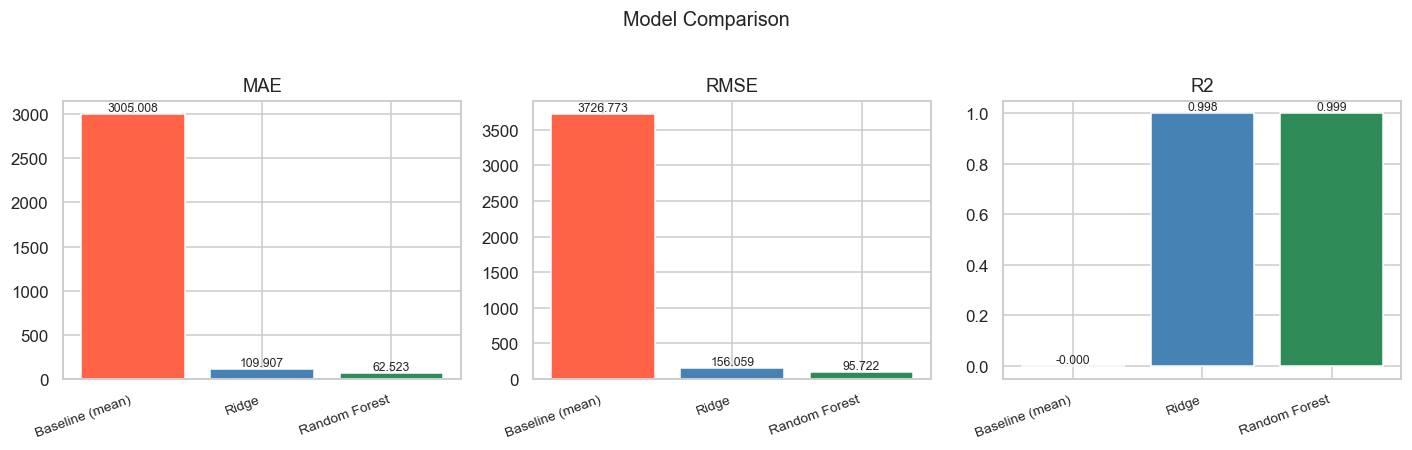

In [16]:
# ── Model comparison bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals, color=['tomato','steelblue','seagreen'])
    ax.set_title(metric); ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("Model Comparison", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

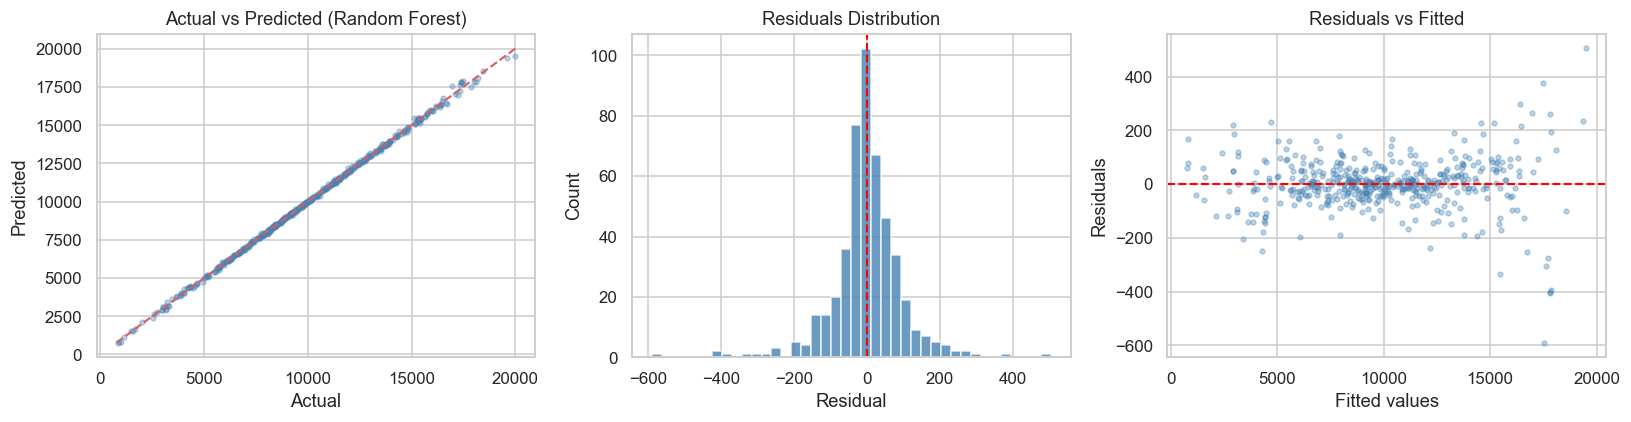

Random Forest — MAE: 62.52  RMSE: 95.72  R²: 0.9993


In [17]:
# Best model: Random Forest
y_best = y_rf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_best, alpha=0.35, s=10, color='steelblue')
lims = [min(y_test.min(), y_best.min()), max(y_test.max(), y_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.4)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (Random Forest)")

# Residuals distribution
residuals = y_test.values - y_best
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.4)
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].set_title("Residuals Distribution")

# Residuals vs Fitted
axes[2].scatter(y_best, residuals, alpha=0.35, s=10, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.4)
axes[2].set_xlabel("Fitted values"); axes[2].set_ylabel("Residuals")
axes[2].set_title("Residuals vs Fitted")

plt.tight_layout(); plt.show()

print(f"Random Forest — MAE: {results['Random Forest']['MAE']:.2f}  "
      f"RMSE: {results['Random Forest']['RMSE']:.2f}  "
      f"R²: {results['Random Forest']['R2']:.4f}")

## 9. Feature Importance

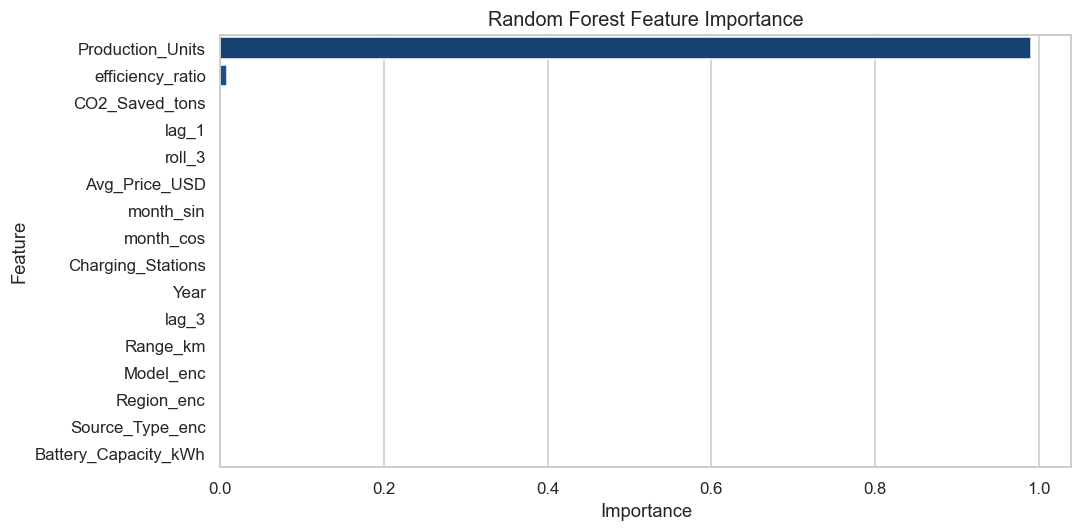

             Feature  Importance
    Production_Units    0.990439
    efficiency_ratio    0.008399
      CO2_Saved_tons    0.000205
               lag_1    0.000154
              roll_3    0.000094
       Avg_Price_USD    0.000091
           month_sin    0.000091
           month_cos    0.000087
   Charging_Stations    0.000080
                Year    0.000078
               lag_3    0.000073
            Range_km    0.000067
           Model_enc    0.000058
          Region_enc    0.000034
     Source_Type_enc    0.000030
Battery_Capacity_kWh    0.000018


In [18]:
imp = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=imp, palette='Blues_r')
plt.title("Random Forest Feature Importance", fontsize=13)
plt.tight_layout(); plt.show()

print(imp.to_string(index=False))

## 10. Save Model & Artefacts

In [19]:
import joblib, pickle

# Save model
joblib.dump(rf, "tesla_delivery_model.pkl")

# Save scaler and encoders
joblib.dump(scaler, "scaler.pkl")
with open("encoders.pkl", "wb") as f:
    pickle.dump({'region': le_region, 'model': le_model, 'source': le_source}, f)

print("Saved: tesla_delivery_model.pkl")
print("Saved: scaler.pkl")
print("Saved: encoders.pkl")
print()
print("To reload:")
print("  model    = joblib.load('tesla_delivery_model.pkl')")
print("  scaler   = joblib.load('scaler.pkl')")

Saved: tesla_delivery_model.pkl
Saved: scaler.pkl
Saved: encoders.pkl

To reload:
  model    = joblib.load('tesla_delivery_model.pkl')
  scaler   = joblib.load('scaler.pkl')


## Pipeline Summary

| Step | What was done | Key fix applied |
|---|---|---|
| Null audit | 0 nulls; defensive fill included | — |
| EDA | 5 plots: time trend, YoY growth, model share, region trend, heatmap | Added 4 missing plots |
| Feature engineering | Cyclical month, efficiency ratio, lag-1/lag-3, rolling-3 | New — was missing entirely |
| Encoding | Separate `LabelEncoder` per column | Fixed shared-encoder bug |
| Train/test split | Hard date boundary: 2015–2023 train · 2024–2025 test | Fixed random shuffle data leakage |
| Modelling | Baseline + Ridge + Random Forest | Added baseline & linear benchmark |
| Evaluation | MAE, RMSE, R² + actual-vs-predicted + residual plots | Added diagnostic plots |
| Persistence | Model + scaler + encoders saved | — |